# Guide final — Le workflow Machine Learning complet

## Objectifs d'apprentissage

À la fin de ce guide, tu seras capable de :

✅ Séparer tes données en **train / validation / test** et savoir à quoi sert chaque part
✅ Construire un **preprocessing générique** avec `ColumnTransformer` (numérique + catégoriel)
✅ Assembler preprocessing et modèle dans une **`Pipeline`**
✅ Laisser **`GridSearchCV`** choisir le **modèle** *et* ses **hyperparamètres** par **validation croisée**
✅ **Évaluer** honnêtement ton modèle, puis **prédire** sur de nouvelles données
✅ **Sauvegarder** ton modèle et le réutiliser plus tard

---

## Comment utiliser ce guide

Ce notebook est un **squelette réutilisable** : il fonctionne pour **n'importe quel modèle** de scikit-learn.
Chaque cellule est commentée étape par étape. Pour l'adapter à un nouveau projet, tu ne changes en réalité que **trois choses** :

1. le **chargement des données** (étape 1),
2. les **modèles candidats** et leurs hyperparamètres, dans la grille (étape 6),
3. la **métrique** (`scoring`) adaptée à ton problème (étape 7).

Tout le reste — split, preprocessing, entraînement, évaluation, prédiction — ne bouge pas.

> ⚠️ Les **métriques** ne sont pas expliquées ici : on montre *où* et *comment* on les appelle, pas comment les interpréter. Ce sera l'objet d'une leçon dédiée.

---

## Étape 0 — Les importations

Toujours les mêmes briques, quel que soit le projet. On les regroupe en haut du notebook.

In [1]:
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# --- Separation des donnees ---------------------------------------------
from sklearn.model_selection import train_test_split, GridSearchCV

# --- Preprocessing -------------------------------------------------------
from sklearn.impute import SimpleImputer                    # remplir les valeurs manquantes
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer               # traiter num et cat differemment
from sklearn.pipeline import Pipeline                       # enchainer les etapes
from sklearn.base import clone                              # dupliquer un modele non entraine

# --- Modeles (on en importe plusieurs : ils sont interchangeables) -------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- Evaluation ----------------------------------------------------------
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Sauvegarde ----------------------------------------------------------
import joblib

RANDOM_STATE = 42   # une seule graine pour tout le notebook = resultats reproductibles

print("Imports OK")

Imports OK


---

## Étape 1 — Charger les données

C'est la **seule** partie vraiment spécifique à ton projet. En vrai, ce sera souvent :

```python
df = pd.read_csv("mes_donnees.csv")
```

Ici, on utilise un dataset intégré à scikit-learn pour que le notebook tourne sans fichier externe.
On lui **ajoute volontairement deux colonnes catégorielles et des valeurs manquantes** : c'est ce qui rend le guide *général*, puisqu'un vrai jeu de données mélange presque toujours ces trois cas de figure.

> On garde **10 colonnes numériques** : assez pour que le modèle apprenne des règles qui tiennent hors du train — c'est la condition pour que le diagnostic de surapprentissage de l'étape 8.2 soit lisible.


In [2]:
from sklearn.datasets import load_breast_cancer

# Dataset reel integre a scikit-learn (classification binaire, 569 lignes)
donnees = load_breast_cancer(as_frame=True)
df = donnees.frame.copy()

# On ne garde que 10 colonnes numeriques sur les 30 : assez pour rester lisible,
# assez pour que le modele generalise (peu de colonnes = modele qui colle au train).
COLONNES = [
    "mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness",
    "mean concavity", "mean concave points",
    "worst radius", "worst texture", "worst concave points",
]
df = df[COLONNES + ["target"]]

# --- On fabrique un dataset "realiste" ----------------------------------
rng = np.random.default_rng(RANDOM_STATE)

# 1) deux colonnes CATEGORIELLES (texte) : le cas le plus courant en entreprise
df["centre"]    = rng.choice(["Paris", "Lyon", "Lille"], size=len(df))
df["technicien"] = rng.choice(["A", "B", "C", "D"], size=len(df))

# 2) des VALEURS MANQUANTES (NaN), inevitables dans la vraie vie
trous = rng.choice(len(df), size=40, replace=False)
df.loc[trous, "mean texture"] = np.nan
df.loc[rng.choice(len(df), size=25, replace=False), "centre"] = np.nan

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean concavity,mean concave points,worst radius,worst texture,worst concave points,target,centre,technicien
0,17.99,10.38,122.80,1001.0,0.11840,0.3001,0.14710,25.38,17.33,0.2654,0,Paris,C
1,20.57,17.77,132.90,1326.0,0.08474,0.0869,0.07017,24.99,23.41,0.1860,0,Lille,D
2,19.69,21.25,130.00,1203.0,0.10960,0.1974,0.12790,23.57,25.53,0.2430,0,NaN,B
3,11.42,20.38,77.58,386.1,0.14250,0.2414,0.10520,14.91,26.50,0.2575,0,Lyon,B
4,20.29,NaN,135.10,1297.0,0.10030,0.1980,0.10430,22.54,16.67,0.1625,0,Lyon,A


In [3]:
# Toujours regarder ses donnees AVANT de modeliser
print("Dimensions :", df.shape)
print("\nValeurs manquantes par colonne :")
print(df.isna().sum())
print("\nRepartition de la cible :")
print(df["target"].value_counts())

Dimensions : (569, 13)

Valeurs manquantes par colonne :
mean radius              0
mean texture            40
mean perimeter           0
mean area                0
mean smoothness          0
mean concavity           0
mean concave points      0
worst radius             0
worst texture            0
worst concave points     0
target                   0
centre                  25
technicien               0
dtype: int64

Repartition de la cible :
target
1    357
0    212
Name: count, dtype: int64


<div class="story">

💡 **Pourquoi vérifier la répartition de la cible ?**

Si une classe représente 95 % des lignes, un modèle qui prédit toujours cette classe aura 95 % d'accuracy sans rien avoir appris. Le savoir dès le départ évite de se réjouir trop vite — et justifie le `stratify=y` de l'étape suivante.

</div>

---

## Étape 2 — Séparer les features (X) de la cible (y)

Convention universelle en Machine Learning :

- **`X`** = les *features*, les colonnes qui servent à prédire (la « question »).
- **`y`** = la *target* / cible, la colonne à prédire (la « réponse »).

In [4]:
CIBLE = "target"                 # <-- a changer selon ton dataset

X = df.drop(columns=[CIBLE])     # toutes les colonnes SAUF la cible
y = df[CIBLE]                    # uniquement la cible

print("X :", X.shape, "| y :", y.shape)
print("Colonnes de X :", list(X.columns))

X : (569, 12) | y : (569,)
Colonnes de X : ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean concavity', 'mean concave points', 'worst radius', 'worst texture', 'worst concave points', 'centre', 'technicien']


---

## Étape 3 — Séparer train / validation / test

C'est l'étape la plus importante du guide, et celle qu'on bâcle le plus souvent.

### Les trois jeux et leur rôle

| Jeu | Proportion typique | À quoi il sert | Le modèle le « voit » ? |
|---|---|---|---|
| **Train** | ~60 % | Le modèle **apprend** dessus (`.fit()`) | Oui, en permanence |
| **Validation** | ~20 % | **Choisir** : quel modèle ? quels hyperparamètres ? | Non pour apprendre, oui pour décider |
| **Test** | ~20 % | **Estimer** la performance finale, une seule fois | Jamais, jusqu'à la toute fin |

### Pourquoi trois jeux et pas deux ?

Avec seulement train/test, tu utilises le test pour choisir tes hyperparamètres… puis tu annonces le score de ce même test comme performance finale. Le test a alors **influencé** tes choix : il n'est plus « inconnu », et ton score est **optimiste**. C'est une forme discrète de *data leakage*.

Le jeu de **validation** absorbe ce rôle de « brouillon » : on essaie, on compare, on se trompe dessus autant qu'on veut. Le **test** reste sous scellé.

<div class="story">

⚠️ **La règle d'or**

Le jeu de **test** ne sert **qu'une seule fois**, tout à la fin.
Si tu regardes ton score de test, que tu changes un hyperparamètre, et que tu re-testes… tu viens de transformer ton test en validation. Ton score n'est plus honnête.

</div>

### Comment faire en pratique : deux `train_test_split` successifs

Il n'existe pas de fonction qui découpe en trois d'un coup. On applique donc `train_test_split` **deux fois** :

```
X (100 %)
 ├── split n°1 (test_size=0.2) ──> X_test  (20 %)   [mis sous scellé]
 └── X_temp (80 %)
      └── split n°2 (test_size=0.25) ──> X_val (20 % du total)
                                    └──> X_train (60 % du total)
```

> Attention au `0.25` du second split : 25 % de 80 %, cela fait bien **20 %** du total.

In [5]:
# --- SPLIT 1 : on met le TEST de cote immediatement -----------------------
# C'est la toute premiere chose a faire, AVANT tout preprocessing ou exploration poussee.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,              # 20 % pour le test final
    random_state=RANDOM_STATE,  # reproductibilite : meme decoupage a chaque execution
    stratify=y                  # garde la meme proportion de classes dans chaque jeu
)

# --- SPLIT 2 : on coupe le reste en train + validation --------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,             # 25 % de 80 % = 20 % du total
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train      : {len(X_train):>3} lignes  ({len(X_train)/len(X):.0%})")
print(f"Validation : {len(X_val):>3} lignes  ({len(X_val)/len(X):.0%})")
print(f"Test       : {len(X_test):>3} lignes  ({len(X_test)/len(X):.0%})")

Train      : 341 lignes  (60%)
Validation : 114 lignes  (20%)
Test       : 114 lignes  (20%)


<div class="story">

ℹ️ **`stratify=y`, à ne jamais oublier en classification**

Sans lui, le découpage est purement aléatoire : ton test pourrait contenir 80 % d'une classe et ton train 40 %. Avec `stratify=y`, **chaque jeu conserve la répartition d'origine** des classes.
En **régression** (cible continue), on ne l'utilise pas : on écrit simplement `train_test_split(X, y, test_size=0.2, random_state=42)`.

</div>

### Et la validation croisée dans tout ça ?

Un jeu de validation unique a un défaut : le score dépend de **quelles lignes** sont tombées dedans. Avec un peu de malchance, un mauvais hyperparamètre peut sembler meilleur qu'un bon.

La **validation croisée** (`cv`) règle ça : elle découpe le train en *k* plis, entraîne *k* fois, et fait la **moyenne** des *k* scores. C'est exactement ce que `GridSearchCV` fait pour toi à l'étape 7 — c'est pourquoi on lui donne **uniquement le train**.

Les deux approches ne s'opposent pas, elles se complètent :

- la **CV sur le train** → tout ce qui tient dans une grille : les *hyperparamètres*, et même le *choix du modèle* (on le verra à l'étape 6) ;
- le **jeu de validation** → **confirmer** ce choix sur des données qui n'ont participé à aucune décision, et arbitrer entre des candidats non comparables dans une même grille — le tout sans toucher au test.

<div class="story">

💡 **Si ton dataset est petit** (quelques centaines de lignes), garder 20 % en validation coûte cher en données d'entraînement. Dans ce cas, beaucoup de praticiens font simplement **train / test**, et laissent la validation croisée jouer le rôle du jeu de validation. Le découpage en trois reste la référence pédagogique et la norme dès que les données sont abondantes.

</div>

---

## Étape 4 — Le preprocessing

Les modèles ne savent lire que des **nombres**, sans **trous**, et souvent à la **même échelle**. Il faut donc préparer les colonnes — mais pas de la même façon selon leur type :

| Type de colonne | Traitement | Pourquoi |
|---|---|---|
| **Numérique** (`age`, `prix`) | `SimpleImputer(median)` → `StandardScaler` | Boucher les trous, puis mettre toutes les colonnes sur la même échelle |
| **Catégorielle** (`ville`, `type`) | `SimpleImputer(most_frequent)` → `OneHotEncoder` | Boucher les trous, puis transformer le texte en colonnes 0/1 |

### D'abord : détecter les colonnes automatiquement

On ne va pas écrire les noms à la main — ce guide doit marcher sur n'importe quel dataset.

In [6]:
# Detection automatique du type de chaque colonne : ce code marche sur n'importe quel DataFrame
colonnes_num = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
colonnes_cat = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Colonnes numeriques   :", colonnes_num)
print("Colonnes categorielles:", colonnes_cat)

Colonnes numeriques   : ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean concavity', 'mean concave points', 'worst radius', 'worst texture', 'worst concave points']
Colonnes categorielles: ['centre', 'technicien']


### Ensuite : une mini-pipeline par type de colonne

Chaque type reçoit sa propre petite chaîne de traitement, exécutée dans l'ordre.

In [7]:
# Chaine de traitement des colonnes NUMERIQUES
pipeline_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # 1) NaN -> MEDIANE du train (choix arrete : plus robuste aux valeurs extremes que la moyenne)
    ("scaler",  StandardScaler()),                  # 2) centre-reduit : moyenne 0, ecart-type 1
])

# Chaine de traitement des colonnes CATEGORIELLES
pipeline_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),          # 1) NaN -> valeur la plus frequente
    ("encoder", OneHotEncoder(handle_unknown="ignore",             # 2) texte -> colonnes 0/1
                              sparse_output=False)),
])

<div class="story">

ℹ️ **`handle_unknown="ignore"` : le détail qui sauve la production**

Si une catégorie apparaît en test (ou en production) sans avoir jamais été vue en train — une nouvelle ville, un nouveau produit — l'encodeur planterait. Avec `ignore`, il génère simplement une ligne de zéros au lieu de lever une erreur.

*Note : `sparse_output=False` s'écrit `sparse=False` sur les versions de scikit-learn antérieures à 1.2.*

</div>

### Enfin : `ColumnTransformer` applique la bonne chaîne à la bonne colonne

`ColumnTransformer` est l'aiguilleur : il envoie les colonnes numériques dans `pipeline_num`, les catégorielles dans `pipeline_cat`, et recolle les résultats côte à côte.

In [8]:
preprocesseur = ColumnTransformer(
    transformers=[
        ("num", pipeline_num, colonnes_num),   # (nom, quoi appliquer, sur quelles colonnes)
        ("cat", pipeline_cat, colonnes_cat),
    ],
    remainder="drop",   # les colonnes non citees sont supprimees ("passthrough" pour les garder telles quelles)
)

preprocesseur

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

---

## Étape 5 — La pipeline complète : preprocessing + modèle

On emboîte maintenant le préprocesseur et le modèle dans **un seul objet**. C'est le cœur du guide.

### Pourquoi c'est indispensable (et pas juste « plus propre »)

1. **Zéro data leakage.** Le `.fit()` du scaler et de l'imputer n'est calculé que sur les données d'entraînement. Sur le test, la pipeline appelle automatiquement `.transform()` seul, avec les statistiques du train.
2. **Un seul objet à manipuler.** `.fit()`, `.predict()`, `.score()` : la pipeline se comporte exactement comme un modèle.
3. **Compatible `GridSearchCV`.** Le preprocessing est refait *à l'intérieur de chaque pli* de validation croisée — c'est la seule façon d'avoir des scores honnêtes.
4. **Déployable.** Un `joblib.dump()` sauvegarde la chaîne entière, du CSV brut à la prédiction.

<div class="story">

⚠️ **L'erreur classique**

Scaler *avant* le split, ou scaler `X` en entier d'un coup : la moyenne utilisée contient alors de l'information venue du test. Le score paraît excellent… et s'effondre en production. La pipeline rend cette erreur **impossible**.

</div>

In [9]:
# LA pipeline complete. C'est ICI qu'on choisit le modele -- la seule ligne a changer.
pipeline = Pipeline([
    ("preprocessing", preprocesseur),                          # etape 1 : preparer les donnees
    ("modele",        RandomForestClassifier(random_state=RANDOM_STATE)),  # etape 2 : le modele
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('modele', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

<div class="story">

💡 **La dernière étape est le modèle, les précédentes sont des *transformers***

C'est la règle d'une `Pipeline` : toutes les étapes sauf la dernière doivent savoir `transform()`. La dernière, elle, doit savoir `fit()` et `predict()`.
Pour changer de modèle, tu remplaces **uniquement** `RandomForestClassifier(...)` par `LogisticRegression(...)`, `SVC()`, `Ridge()`… et tout le reste du notebook continue de fonctionner. Mieux : à l'étape 6, on laissera carrément `GridSearchCV` choisir le modèle à notre place.

</div>

---

## Étape 6 — La grille d'hyperparamètres

### Paramètre ≠ hyperparamètre

- Un **paramètre** est *appris* par le modèle pendant l'entraînement (les coefficients d'une régression, les seuils d'un arbre). Tu n'y touches pas.
- Un **hyperparamètre** est *choisi par toi* **avant** l'entraînement (`max_depth`, `C`, `n_estimators`). C'est ce que `GridSearchCV` va tester à ta place.

### La syntaxe `etape__hyperparametre`

Dans une pipeline, on désigne un hyperparamètre par le **nom de l'étape**, **deux underscores**, puis le nom de l'hyperparamètre :

```
"modele__max_depth"                          -> le max_depth de l'etape "modele"
"preprocessing__num__imputer__strategy"      -> on descend etape par etape dans les sous-pipelines
```

Ce double underscore te permet de régler **n'importe quel composant** de la chaîne — y compris le preprocessing lui-même, ce qui est très puissant : on peut demander à la grille de choisir *elle-même* si la médiane ou la moyenne imputait mieux.

### Le modèle aussi est un paramètre réglable

Voici l'idée qui change tout : dans la pipeline, l'étape `"modele"` est un paramètre **comme les autres**. On peut donc demander à `GridSearchCV` non seulement *quels hyperparamètres* prendre, mais aussi **quel modèle** choisir.

C'est bien plus rigoureux que d'entraîner deux modèles à la main puis de comparer leurs scores : ici, tous les candidats sont évalués sur **exactement les mêmes plis** de validation croisée. La comparaison est équitable par construction.

Pour cela, `param_grid` accepte une **liste de dictionnaires**. Chaque dictionnaire décrit un **scénario** complet : un modèle **et** les hyperparamètres qui lui sont propres.

<div class="story">

⚠️ **Pourquoi une liste, et pas un seul dictionnaire ?**

Parce que les hyperparamètres ne sont pas transposables : `C` n'existe pas pour un RandomForest, `max_depth` n'existe pas pour une régression logistique. Dans un dictionnaire unique, GridSearch tenterait de croiser les deux et planterait. La liste **isole chaque modèle avec ses propres hyperparamètres**.

</div>

C'est cette version — **deux modèles en concurrence** — qu'on suit jusqu'à la fin du guide.

In [10]:
# Astuce : cette commande liste TOUS les noms d'hyperparametres reglables de ta pipeline
# (a decommenter quand tu ne connais pas le nom exact a utiliser)
# pipeline.get_params().keys()

param_grid = [
    # --- Scenario 1 : RandomForest et SES hyperparametres ---
    {
        # Noter les CROCHETS : "modele" recoit une LISTE de valeurs a tester, comme tout hyperparametre
        "modele":                   [RandomForestClassifier(random_state=RANDOM_STATE)],
        "modele__n_estimators":     [100, 200],
        "modele__max_depth":        [None, 5, 10],
        "modele__min_samples_leaf": [1, 5],
    },
    # --- Scenario 2 : Regression logistique et SES hyperparametres ---
    {
        "modele":    [LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)],
        # C balaye 7 ordres de grandeur : du modele tres bride (0.001) au modele libre (1000).
        # Cette amplitude sert deux fois : ici pour CHOISIR, et a l'etape 8.2 pour DIAGNOSTIQUER.
        "modele__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    },

    # On POURRAIT aussi optimiser le preprocessing, avec la meme syntaxe :
    # "preprocessing__num__imputer__strategy": ["median", "mean"],
    # Ici on ne le fait pas : le choix de la mediane est deja acte dans la pipeline.
]

# Les dictionnaires s'AJOUTENT, ils ne se croisent pas : 12 + 7 = 19 scenarios (et non 12 x 7)
n_scenarios = sum(int(np.prod([len(v) for v in bloc.values()])) for bloc in param_grid)
print(f"{n_scenarios} scenarios x 5 plis = {n_scenarios * 5} entrainements")


19 scenarios x 5 plis = 95 entrainements


### Faut-il écrire les hyperparamètres dans la pipeline **ou** dans la grille ?

La question revient toujours, et la réponse tient en une phrase : **la pipeline dit *quoi faire*, la grille dit *quoi faire varier***.

En interne, pour chaque combinaison, `GridSearchCV` repart de ta pipeline et remplace uniquement les paramètres cités dans la grille :

```python
modele_a_tester = clone(pipeline).set_params(modele__max_depth=5)
```

Donc un hyperparamètre présent dans la grille **écrase** la valeur écrite dans la pipeline ; un hyperparamètre absent de la grille **garde** celle de la pipeline. Écrire la même chose aux deux endroits n'est jamais utile, et rend le code trompeur.

| Nature de l'argument | Exemples | Où l'écrire |
|---|---|---|
| **Technique** (pas un levier de performance) | `random_state`, `max_iter`, `n_jobs`, `handle_unknown` | **Pipeline** |
| **Choix déjà arrêté** | `strategy="median"` quand tu sais que c'est le bon | **Pipeline** |
| **Valeur inconnue, à chercher** | `max_depth`, `C`, `alpha`, `n_estimators`, et le **modèle** lui-même | **Grille** |

<div class="story">

ℹ️ **Le modèle écrit dans la pipeline n'est plus qu'un emplacement**

Puisque notre grille fournit le modèle, le `RandomForestClassifier()` écrit à l'étape 5 dans `Pipeline([..., ("modele", ...)])` sera **systématiquement remplacé** : c'est devenu un simple *placeholder*. Application directe de la règle ci-dessus — ce qui est dans la grille écrase ce qui est dans la pipeline.

</div>

<div class="story">

⚠️ **Ne mets jamais `random_state` dans la grille**

Optimiser une graine aléatoire revient à sélectionner le tirage le plus flatteur : le score grimpe, mais ne se reproduira pas sur de nouvelles données. Ce n'est pas un hyperparamètre, c'est un réglage de reproductibilité.

</div>

<div class="story">

💡 **Le réflexe qui fait gagner du temps**

Ta pipeline doit rester **exécutable seule**, sans GridSearch. Lance `pipeline.fit(X_train, y_train)` une fois avant la grille : une erreur de structure apparaît en 2 secondes, au lieu de te faire attendre 80 entraînements.

</div>

<div class="story">

⚠️ **Attention à l'explosion combinatoire**

Une grille teste **toutes** les combinaisons possibles : 4 hyperparamètres à 5 valeurs chacun font 625 combinaisons, soit 3 125 entraînements en `cv=5`. Et comparer 4 modèles × 20 combinaisons chacun, c'est 400 entraînements.
Commence donc **large et grossier** : peu de valeurs par modèle, bien espacées. L'objectif d'une première grille est d'**éliminer** les modèles clairement inadaptés, pas de les régler finement — tu affineras ensuite la grille du seul gagnant.
Si la grille reste trop lourde, remplace `GridSearchCV` par **`RandomizedSearchCV`** : mêmes arguments, mais il tire `n_iter` combinaisons au hasard au lieu de toutes les tester.

</div>

---

## Étape 7 — Entraîner : `GridSearchCV` + validation croisée

`GridSearchCV` combine deux idées en un seul objet :

1. il parcourt **tous les scénarios** de `param_grid` — ici les 19, modèles compris ;
2. il évalue chacun en **validation croisée** (`cv=5` : le train est découpé en 5 plis, le modèle est entraîné 5 fois, on garde la moyenne des 5 scores).

À la fin, il ré-entraîne automatiquement le meilleur scénario sur **tout** le train. Ce `.fit()` répond donc d'un coup aux deux questions : *quel modèle ?* et *quels hyperparamètres ?*

> On lui passe **`X_train` uniquement**. Ni la validation, ni le test : il se débrouille avec ses propres plis internes.

In [11]:
grille = GridSearchCV(
    estimator=pipeline,        # la pipeline COMPLETE (pas juste le modele !)
    param_grid=param_grid,     # les scenarios a tester (ici une LISTE de dictionnaires)
    cv=5,                      # validation croisee a 5 plis
    scoring="accuracy",        # la metrique qui decide du "meilleur" (a adapter au probleme)
    n_jobs=-1,                 # utilise tous les coeurs du processeur = plus rapide
    verbose=1,                 # affiche l'avancement
    refit=True,                # re-entraine le meilleur modele sur tout le train (comportement par defaut)
    return_train_score=True,   # garde AUSSI le score sur les plis d'entrainement -> servira au diagnostic de l'etape 8.2
)

# Un seul .fit() : preprocessing + entrainement + validation croisee + selection
grille.fit(X_train, y_train)

print("\nEntrainement termine")


Fitting 5 folds for each of 19 candidates, totalling 95 fits



Entrainement termine


<div class="story">

⚠️ **Une seule règle pour tous les candidats**

`scoring` dépend du **problème**, jamais du modèle. Comparer un RandomForest en `accuracy` et une régression logistique en `f1` n'aurait aucun sens : ce serait classer deux coureurs, l'un au chrono et l'autre à la distance.

C'est aussi impossible techniquement : `scoring` est un argument de `GridSearchCV`, pas une étape de la pipeline. `param_grid` ne peut contenir que ce que `set_params()` sait régler — donc des étapes et leurs hyperparamètres. Ce qui varie d'un modèle à l'autre, ce sont les **hyperparamètres** (`C` vs `max_depth`), d'où la liste de dictionnaires. La métrique, elle, reste dehors, **commune à tous**.

</div>

### Regarder plusieurs métriques à la fois

Tu peux demander plusieurs métriques — elles seront calculées pour **tous** les candidats, mais **une seule** désignera le gagnant, celle indiquée par `refit` :

```python
GridSearchCV(pipeline, param_grid, cv=5,
             scoring=["accuracy", "f1", "roc_auc"],   # calculees pour tous les scenarios
             refit="f1")                              # celle qui DECIDE
```

`cv_results_` contient alors `mean_test_accuracy`, `mean_test_f1`, `mean_test_roc_auc` : pratique pour regarder un modèle sous plusieurs angles sans relancer la grille. Mais `best_params_`, `best_score_` et `best_estimator_` ne dépendent que de la métrique de `refit` — le classement reste fondé sur une règle unique.

<div class="story">

ℹ️ **Deux conséquences du mode multi-métriques**

`refit` devient **obligatoire** : avec plusieurs métriques, sklearn ne peut plus deviner laquelle utiliser pour ré-entraîner le gagnant.
Et les colonnes de rang deviennent `rank_test_f1`, `rank_test_accuracy`… : le `rank_test_score` générique disparaît. Pense à adapter les `sort_values()` de la cellule suivante.

</div>

<div class="story">

⚠️ **La seule métrique qui dépende vraiment du modèle**

`roc_auc` a besoin de `predict_proba` ou `decision_function`. Un `SVC()` n'en a pas par défaut : la grille échouera. Cela ne se règle pas en changeant de métrique selon le modèle, mais en donnant au modèle ce qui lui manque — ici `SVC(probability=True)`.

</div>

### Lire les résultats

Trois attributs suffisent :

- **`best_params_`** : le meilleur scénario trouvé — **modèle compris**, sous la clé `"modele"` ;
- **`best_score_`** : son score **moyen de validation croisée** (calculé sur le train, pas sur le test) ;
- **`best_estimator_`** : la pipeline complète, déjà ré-entraînée, **prête à prédire**.

In [12]:
# Le modele gagnant se lit dans best_params_["modele"]
print("Modele retenu :", grille.best_params_["modele"].__class__.__name__)

print("\nSes hyperparametres :")
for nom, valeur in grille.best_params_.items():
    if nom != "modele":                     # deja affiche ci-dessus
        print(f"   {nom:<28} = {valeur}")

print(f"\nMeilleur score en validation croisee : {grille.best_score_:.3f}")

# LE modele final, deja entrainé : c'est lui qu'on suit jusqu'a la fin du guide
meilleur_modele = grille.best_estimator_

Modele retenu : LogisticRegression

Ses hyperparametres :
   modele__C                    = 1

Meilleur score en validation croisee : 0.974


In [13]:
# Le classement des 19 scenarios : c'est ce tableau qui JUSTIFIE le choix du modele
resultats = pd.DataFrame(grille.cv_results_)
resultats["nom_modele"] = resultats["param_modele"].apply(lambda m: m.__class__.__name__)

resultats[["nom_modele", "params", "mean_test_score", "std_test_score", "rank_test_score"]] \
    .sort_values("rank_test_score") \
    .head(8)

,nom_modele,params,mean_test_score,std_test_score,rank_test_score
15,LogisticRegression,"{'modele': LogisticRegression(max_iter=5000, r...",0.973529,0.021613,1
16,LogisticRegression,"{'modele': LogisticRegression(max_iter=5000, r...",0.967647,0.026956,2
9,RandomForestClassifier,{'modele': RandomForestClassifier(random_state...,0.961807,0.017704,3
1,RandomForestClassifier,{'modele': RandomForestClassifier(random_state...,0.961807,0.017704,3
4,RandomForestClassifier,{'modele': RandomForestClassifier(random_state...,0.961807,0.017704,3
5,RandomForestClassifier,{'modele': RandomForestClassifier(random_state...,0.961807,0.019998,3
17,LogisticRegression,"{'modele': LogisticRegression(max_iter=5000, r...",0.961765,0.042214,7
14,LogisticRegression,"{'modele': LogisticRegression(max_iter=5000, r...",0.958951,0.017130,8


In [14]:
# Vue d'ensemble : quel modele s'en sort le mieux, en moyenne et au meilleur de sa forme ?
resultats.groupby("nom_modele")["mean_test_score"].agg(["mean", "max", "count"]).round(3)

,mean,max,count
nom_modele,,,
LogisticRegression,0.936,0.974,7
RandomForestClassifier,0.958,0.962,12


<div class="story">

💡 **Tous les scénarios sont évalués sur exactement les mêmes plis**

C'est ce qui rend la comparaison **équitable par construction**. Si tu entraînes deux modèles à la main sur deux découpages différents, l'écart que tu observes peut venir du hasard du découpage plutôt que du modèle lui-même.

</div>

---

## Étape 8 — Évaluer

L'évaluation se fait en **trois temps**, et l'ordre n'est pas négociable :

| | Sur quoi | Combien de fois | Peut encore changer le modèle ? |
|---|---|---|---|
| **8.1 — Confirmer** | validation | autant qu'on veut | oui |
| **8.2 — Diagnostiquer le surapprentissage** | train vs validation croisée | autant qu'on veut | oui |
| **8.3 — Le verdict final** | test | **une seule** | non, plus rien ne bouge |

Tout ce qui peut encore modifier le modèle se passe **avant** d'ouvrir le test. Le surapprentissage se diagnostique donc en 8.2, pas après : un diagnostic posé sur le test ne servirait à rien, puisqu'on n'aurait plus le droit d'agir dessus.

> Rappel : on ne détaille pas ici la **signification** des métriques (accuracy, précision, rappel, F1, matrice de confusion). On montre uniquement **comment** les obtenir.

### 8.1 — Sur la validation : confirmer le choix de GridSearch

Le choix du modèle et des hyperparamètres est déjà fait : c'est le travail qu'ont accompli les étapes 6 et 7, par validation croisée sur le train.

Le jeu de validation sert ici à autre chose : **vérifier ce choix sur des données qui n'ont participé à aucune décision**. `best_score_` a beau être une moyenne sur 5 plis, il reste le score de la combinaison qu'on a retenue *parce qu'elle sortait en tête* — il est donc un peu optimiste par construction. La validation offre un second avis indépendant, sans entamer le test.


In [15]:
# Le score de CV (qui a servi a CHOISIR) face au score de validation (qui n'a rien choisi)
print(f"Score en validation croisee (train) : {grille.best_score_:.3f}")
print(f"Score sur la validation             : {meilleur_modele.score(X_val, y_val):.3f}")

# Deux ecarts proches = le choix de GridSearch tient la route.
# Un score de validation nettement plus bas = la grille a sur-optimise sur les plis du train.

Score en validation croisee (train) : 0.974
Score sur la validation             : 0.965


C'est aussi ici qu'on **arbitre entre des candidats issus de grilles différentes**. GridSearch compare tout ce qui tient dans une même grille ; dès que deux approches ne sont pas comparables ainsi — un preprocessing différent, des colonnes différentes, un modèle d'une autre bibliothèque — le jeu de validation devient le seul terrain commun pour les départager.

In [16]:
# Le candidat : MEME modele gagnant, mais sans les colonnes categorielles.
# Supprimer des colonnes est un choix de preprocessing, pas un hyperparametre :
# GridSearch ne peut pas l'arbitrer, la validation si.
pipeline_sans_cat = Pipeline([
    ("preprocessing", ColumnTransformer([("num", pipeline_num, colonnes_num)])),
    ("modele",        clone(grille.best_params_["modele"])),  # clone = copie NON entrainee
])
pipeline_sans_cat.fit(X_train, y_train)

score_complet  = meilleur_modele.score(X_val, y_val)
score_sans_cat = pipeline_sans_cat.score(X_val, y_val)

print(f"Pipeline complete           : {score_complet:.3f}")
print(f"Sans colonnes categorielles : {score_sans_cat:.3f}")

# En cas d'EGALITE on garde le plus simple : moins de colonnes a collecter,
# nettoyer et maintenir, pour la meme performance. D'ou le > strict.
modele_retenu = meilleur_modele if score_complet > score_sans_cat else pipeline_sans_cat

print("\n-> On garde :", "la pipeline complete" if modele_retenu is meilleur_modele else "la version simplifiee")
print("   C'est ce 'modele_retenu' qu'on suit jusqu'a la fin du guide.")

Pipeline complete           : 0.965
Sans colonnes categorielles : 0.956

-> On garde : la pipeline complete
   C'est ce 'modele_retenu' qu'on suit jusqu'a la fin du guide.


<div class="story">

💡 **À performance égale, choisis toujours le modèle le plus simple**

Deux colonnes de moins, ce sont deux colonnes à ne plus collecter, nettoyer, ni surveiller en production. Une différence de quelques millièmes sur 114 lignes de validation n'est pas un signal : c'est du bruit. La simplicité, elle, est un gain réel.

</div>

### 8.2 — Le modèle sur-apprend-il ?

**Surapprendre, c'est réussir sur les données déjà vues et échouer sur les autres.** Il suffit donc de comparer le score du modèle sur les données qu'il a apprises (le **train**) et sur des données qu'il n'a jamais vues.

Ces données jamais vues, ce sera la **validation** — surtout pas le test. Le test ne s'ouvre qu'une fois, tout à la fin, et un diagnostic sert précisément à **décider si on change quelque chose**. Diagnostiquer sur le test reviendrait à le griller pour rien.

> Le modèle est **déjà entraîné** : on lui redemande simplement son score sur deux jeux différents. Aucun `.fit()` ici.


In [17]:
# modele_retenu est deja entraine : .score() ne fait que predire et comparer
score_train = modele_retenu.score(X_train, y_train)
score_val   = modele_retenu.score(X_val,   y_val)

ecart = score_train - score_val

print(f"Score sur le TRAIN      (deja vu)   : {score_train:.3f}")
print(f"Score sur la VALIDATION (jamais vu) : {score_val:.3f}")
print(f"Ecart                               : {ecart:.3f}")

# Un ecart en pourcentage ne parle a personne. En NOMBRE DE LIGNES, si.
print(f"\n-> soit {ecart * len(y_val):.0f} ligne(s) de plus mal classee(s), sur les {len(y_val)} de la validation")


Score sur le TRAIN      (deja vu)   : 0.977
Score sur la VALIDATION (jamais vu) : 0.965
Ecart                               : 0.012

-> soit 1 ligne(s) de plus mal classee(s), sur les 114 de la validation


### Cet écart est-il grave ?

La bonne façon de lire un écart, c'est de le **traduire en nombre de lignes**. Sur 114 lignes de validation, **une seule ligne pèse 1/114 ≈ 0.009**. Un écart de 0.02, ce sont donc **2 lignes**. Change le `random_state` du découpage, et ces 2 lignes changent de camp.

Autrement dit : **un écart de quelques lignes ne veut rien dire.** Ce n'est pas un petit surapprentissage, c'est du hasard de découpage.

Mais même un écart large ne suffit pas à condamner un modèle. La seule question qui compte est celle-ci :

> **Un modèle plus contraint ferait-il mieux en validation ?**
>
> - **Oui** → il y a bien du surapprentissage à corriger : régularise.
> - **Non** → garde ton modèle, quel que soit l'écart. Un modèle à train 1.00 / validation 0.95 est **meilleur** qu'un modèle à train 0.93 / validation 0.90, malgré un écart trois fois plus grand.

C'est ce qui compte : **le score sur les données jamais vues**, jamais la taille de l'écart.

### La courbe de validation répond à cette question d'un coup

Elle fait varier la complexité du modèle et trace les deux scores côte à côte : on voit d'un regard si un réglage plus contraint ferait mieux, ou si on est déjà au sommet.

Deux points importants sur la cellule qui suit :

- elle porte sur **le modèle retenu** — la régression logistique — car un diagnostic ne vaut que pour le modèle qu'il diagnostique ;
- elle **ne réentraîne rien**. `GridSearchCV` a déjà entraîné ces 7 modèles à l'étape 7 : on relit ses résultats, stockés dans `cv_results_`. C'est précisément à ça que sert le `return_train_score=True` qu'on lui a passé.

La complexité d'une régression logistique se règle d'un seul hyperparamètre, **`C`**, qui se lit à l'envers d'un `max_depth` :

| `C` | Régularisation | Modèle |
|---|---|---|
| **petit** (0.001) | forte | coefficients écrasés vers 0 → **trop simple** |
| **grand** (1000) | quasi nulle | coefficients libres → **colle au train** |


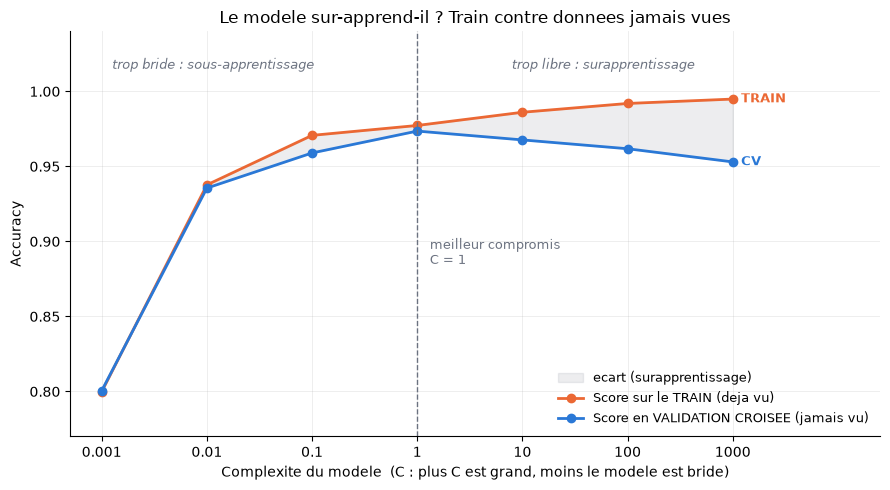

In [18]:
import matplotlib.pyplot as plt

BLEU, ORANGE, GRIS = "#2a78d6", "#eb6834", "#6b7280"

# AUCUN entrainement ici : on relit les resultats deja calcules a l'etape 7.
# On ne garde que les scenarios de regression logistique (le modele retenu).
courbe = resultats[resultats["nom_modele"] == "LogisticRegression"].copy()
courbe["C"] = courbe["param_modele__C"].astype(float)
courbe = courbe.sort_values("C")

valeurs_C = courbe["C"].tolist()
m_train   = courbe["mean_train_score"].to_numpy()   # score sur les plis d'ENTRAINEMENT
m_cv      = courbe["mean_test_score"].to_numpy()    # score sur les plis de VALIDATION de la CV
                                                    # (nom trompeur : ce n'est PAS notre jeu de test)
x = np.arange(len(valeurs_C))
i_best = int(np.argmax(m_cv))

fig, ax = plt.subplots(figsize=(9, 5))

ax.fill_between(x, m_cv, m_train, color=GRIS, alpha=0.12, label="ecart (surapprentissage)")
ax.plot(x, m_train, "-o", color=ORANGE, lw=2, ms=6, label="Score sur le TRAIN (deja vu)")
ax.plot(x, m_cv,    "-o", color=BLEU,   lw=2, ms=6, label="Score en VALIDATION CROISEE (jamais vu)")

ax.axvline(i_best, color=GRIS, ls="--", lw=1)
ax.annotate(f"meilleur compromis\nC = {valeurs_C[i_best]:g}",
            xy=(i_best + 0.12, 0.885), color=GRIS, fontsize=9)
ax.text(0.1, 1.015, "trop bride : sous-apprentissage", color=GRIS, fontsize=9, style="italic")
ax.text(len(x) - 3.1, 1.015, "trop libre : surapprentissage", color=GRIS, fontsize=9, style="italic")

ax.annotate("TRAIN", xy=(x[-1], m_train[-1]), xytext=(6, 0), textcoords="offset points",
            color=ORANGE, fontsize=9, fontweight="bold", va="center")
ax.annotate("CV", xy=(x[-1], m_cv[-1]), xytext=(6, 0), textcoords="offset points",
            color=BLEU, fontsize=9, fontweight="bold", va="center")

ax.set_xticks(x); ax.set_xticklabels([f"{c:g}" for c in valeurs_C])
ax.set_xlabel("Complexite du modele  (C : plus C est grand, moins le modele est bride)")
ax.set_ylabel("Accuracy")
ax.set_title("Le modele sur-apprend-il ? Train contre donnees jamais vues")
ax.set_xlim(-0.3, len(x) + 0.4)
ax.set_ylim(0.77, 1.04)
ax.grid(alpha=0.25, lw=0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


### Lire cette courbe

C'est **la** figure à savoir interpréter. La courbe orange est le score sur ce que le modèle a déjà vu, la bleue sur ce qu'il n'a jamais vu. **Seule la bleue compte** ; l'orange sert uniquement à mesurer l'écart.

- **À gauche (`C` = 0.001)** — les deux courbes sont basses **et collées** : la régularisation est si forte que tous les coefficients sont écrasés vers 0. C'est du **sous-apprentissage**. L'écart est nul, et pourtant le modèle est mauvais : preuve qu'un petit écart n'est pas en soi une bonne nouvelle.
- **Au milieu (`C` = 1)** — la courbe bleue atteint son **maximum**. C'est le meilleur compromis, et c'est exactement la valeur que `GridSearchCV` a retenue à l'étape 7, sans qu'on la lui souffle.
- **À droite (`C` = 100 à 1000)** — l'orange continue de monter pendant que la bleue **redescend**. La zone grise entre les deux, c'est le surapprentissage : le modèle ajuste ses coefficients à des détails du train qui ne servent à rien ailleurs.

La réponse à notre question est donc : **non, notre modèle ne sur-apprend pas**. Aucun `C` plus contraint ne fait mieux que celui retenu — on est au sommet de la courbe bleue.

<div class="story">

💡 **Le signal à retenir**

Ce n'est pas la hauteur de l'écart qui compte, c'est **le moment où la courbe bleue cesse de progresser**. Tout ce que tu gagnes sur le train après ce point est du surapprentissage pur.

</div>

<div class="story">

ℹ️ **Le même diagnostic sur un autre modèle**

Seuls le modèle et l'hyperparamètre à balayer changent :

| Modèle | Hyperparamètre | Sens de lecture |
|---|---|---|
| `LogisticRegression` / `SVC` | `C` | complexité **croissante** avec `C` |
| `Ridge` / `Lasso` | `alpha` | complexité **décroissante** avec `alpha` |
| `DecisionTreeClassifier` | `max_depth` | complexité **croissante** |
| `RandomForestClassifier` | `max_depth`, `min_samples_leaf` | croissante / décroissante |

Trace toujours cette courbe sur **le modèle que tu comptes livrer**, jamais sur un autre.

Si l'hyperparamètre voulu n'est pas dans ta grille, `validation_curve` le balaye pour toi — mais elle, elle réentraîne :

```python
from sklearn.model_selection import validation_curve
scores_train, scores_cv = validation_curve(
    pipeline_diag, X_train, y_train,
    param_name="modele__C", param_range=[0.01, 0.1, 1, 10],
    cv=5, scoring="accuracy", n_jobs=-1,
)
```

</div>


<div class="story">

⚠️ **Ré-entraîner ne répare pas le surapprentissage**

Le réflexe naturel devant un écart trop grand est de relancer l'entraînement. Ça ne sert à rien : avec les mêmes données, les mêmes hyperparamètres et le même `random_state`, `fit()` redonne **exactement** le même modèle. Le surapprentissage n'est pas un accident d'entraînement, c'est une propriété du couple modèle / données.

Ce qui le corrige, c'est de **changer quelque chose** :

- **contraindre le modèle** : `max_depth` plus petit, `min_samples_leaf` plus grand, `C` ou `alpha` plus fort ;
- **simplifier** : moins de features, un modèle moins expressif ;
- **plus de données**, quand c'est possible — le remède le plus efficace ;
- **élargir la grille** vers les valeurs plus régularisées, si le gagnant se trouve au bord de ta grille actuelle.

Et surtout : ces choix se décident sur la **validation** ou la **CV**, jamais sur le test. « Je retente jusqu'à ce que le score de test remonte » revient à laisser le test orienter tes décisions — au bout de trois essais il est **brûlé**, et son score n'estime plus rien d'honnête.

</div>

### 8.3 — Sur le test : le verdict final

Le modèle est confirmé (8.1), son surapprentissage est diagnostiqué (8.2), plus rien ne changera. On peut sortir le test de son scellé.

Ce score-là est ton estimation honnête de la performance en production — c'est celui que tu annonces.


In [19]:
# LE moment unique ou l'on touche au test
y_pred = modele_retenu.predict(X_test)

print(f"Accuracy sur le test : {accuracy_score(y_test, y_pred):.3f}\n")
print("Rapport de classification :")
print(classification_report(y_test, y_pred))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))


Accuracy sur le test : 0.956

Rapport de classification :
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Matrice de confusion :
[[40  2]
 [ 3 69]]


<div class="story">

💡 **Pourquoi les trois scores diffèrent-ils ?**

`best_score_` (validation croisée), score de validation et score de test ne seront jamais identiques : ils sont calculés sur des données différentes. Un écart de quelques lignes est **normal** — c'est le même raisonnement qu'en 8.2.

Le score de test **constate**, il ne diagnostique pas : à ce stade, il est trop tard pour agir dessus. Le diagnostic, c'était l'étape 8.2.

</div>

### 8.4 — Le ré-entraînement final (optionnel mais recommandé)

Attention à ne pas confondre avec ce qui précède : **ici, on ne cherche rien**. Tous les choix sont figés — le modèle, ses hyperparamètres, le preprocessing. On lui donne simplement **plus de données** en réunissant train + validation, ce qui produit un modèle légèrement meilleur.

C'est le seul ré-entraînement légitime : il ne regarde aucun score pour décider quoi que ce soit.


In [20]:
# On repart du modele retenu (structure + hyperparametres figes)...
modele_final = modele_retenu

# ... et on la re-entraine sur train + validation reunis
X_complet = pd.concat([X_train, X_val])
y_complet = pd.concat([y_train, y_val])
modele_final.fit(X_complet, y_complet)

print(f"Re-entraine sur {len(X_complet)} lignes (train + validation)")
print(f"Score sur le test : {modele_final.score(X_test, y_test):.3f}")


Re-entraine sur 455 lignes (train + validation)
Score sur le test : 0.947


---

## Étape 9 — Prédire sur de nouvelles données

C'est le but de tout ce travail. La pipeline accepte des données **brutes** — mêmes colonnes, mêmes noms, valeurs manquantes comprises : elle applique elle-même l'imputation, l'encodage et le scaling, avec les statistiques apprises sur le train.

> ⚠️ Les nouvelles données doivent être un **DataFrame** avec **exactement les mêmes colonnes** (mêmes noms, même ordre) que `X_train`.

In [21]:
# Deux nouveaux cas a predire, tels qu'ils arriveraient dans la vraie vie
nouvelles_donnees = pd.DataFrame({
    "mean radius":          [14.0, 20.5],
    "mean texture":         [np.nan, 22.1],     # une valeur manquante : la pipeline la gere seule
    "mean perimeter":       [92.0, 135.0],
    "mean area":            [600.0, 1300.0],
    "mean smoothness":      [0.10, 0.11],
    "mean concavity":       [0.05, 0.24],
    "mean concave points":  [0.03, 0.13],
    "worst radius":         [16.0, 25.0],
    "worst texture":        [25.0, 30.0],
    "worst concave points": [0.09, 0.24],
    "centre":               ["Paris", "Lyon"],
    "technicien":           ["A", "C"],
})

# La prediction : une seule ligne, aucun preprocessing manuel
predictions = modele_final.predict(nouvelles_donnees)
print("Predictions :", predictions)


Predictions : [1 0]


In [22]:
# En classification, on peut aussi obtenir la PROBABILITE de chaque classe.
# Utile pour nuancer une decision : 0.51 et 0.99 donnent la meme prediction, pas la meme confiance.
probabilites = modele_final.predict_proba(nouvelles_donnees)

resultat = nouvelles_donnees.copy()
resultat["prediction"]  = predictions
resultat["confiance"]   = probabilites.max(axis=1).round(3)
resultat[["centre", "technicien", "prediction", "confiance"]]

,centre,technicien,prediction,confiance
0,Paris,A,1,0.872
1,Lyon,C,0,1.000


---

## Étape 10 — Sauvegarder et recharger le modèle

Un modèle qui vit uniquement dans un notebook meurt à la fermeture du noyau. `joblib` sauvegarde la **pipeline entière** — preprocessing compris — dans un seul fichier.

In [23]:
# Sauvegarde : un seul fichier contient preprocessing + modele + hyperparametres
joblib.dump(modele_final, "modele_final.joblib")
print("Modele sauvegarde -> modele_final.joblib")

# Rechargement : dans un autre script, une API, une app Streamlit...
modele_charge = joblib.load("modele_final.joblib")

# Il predit immediatement, sans re-entrainement ni preprocessing manuel
print("Prediction du modele recharge :", modele_charge.predict(nouvelles_donnees))

Modele sauvegarde -> modele_final.joblib
Prediction du modele recharge : [1 0]


<div class="story">

ℹ️ **Sauvegarde toujours la pipeline, jamais le modèle seul**

Si tu ne sauvegardes que le modèle, tu dois réappliquer à la main — et à l'identique — l'imputation, l'encodage et le scaling au moment de prédire. La moindre différence fausse les résultats en silence. La pipeline embarque tout : c'est ce qui la rend déployable.

</div>

---

## Récapitulatif — Le squelette à copier-coller

Voici tout le workflow condensé. Pour un nouveau projet, tu ne modifies que les trois zones marquées `# <-- A ADAPTER`.

In [ ]:
# =========================================================================
# WORKFLOW ML COMPLET -- squelette generique
# =========================================================================
import pandas as pd, numpy as np, joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

# --- 1. DONNEES ----------------------------------------------------------
df = pd.read_csv("mes_donnees.csv")                    # <-- A ADAPTER
CIBLE = "ma_colonne_cible"                             # <-- A ADAPTER
X, y = df.drop(columns=[CIBLE]), df[CIBLE]

# --- 2. SPLIT train / val / test (60 / 20 / 20) --------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)

# --- 3. PREPROCESSING ----------------------------------------------------
colonnes_num = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
colonnes_cat = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

preprocesseur = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler",  StandardScaler())]), colonnes_num),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("encoder", OneHotEncoder(handle_unknown="ignore",
                                                sparse_output=False))]), colonnes_cat),
])

# --- 4. PIPELINE ---------------------------------------------------------
pipeline = Pipeline([
    ("preprocessing", preprocesseur),
    ("modele",        RandomForestClassifier(random_state=RANDOM_STATE)),  # placeholder : la grille le remplacera
])

# --- 5. GRILLE + ENTRAINEMENT --------------------------------------------
param_grid = [                                         # <-- A ADAPTER
    {"modele": [RandomForestClassifier(random_state=RANDOM_STATE)],
     "modele__max_depth": [None, 5, 10]},
    {"modele": [LogisticRegression(max_iter=1000)],
     "modele__C": [0.1, 1, 10]},
]
grille = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grille.fit(X_train, y_train)
meilleur_modele = grille.best_estimator_          # modele gagnant, deja re-entraine

# --- 6. EVALUATION -------------------------------------------------------
meilleur_modele.score(X_val,  y_val)    # validation : confirmer, arbitrer, autant de fois que necessaire
meilleur_modele.score(X_test, y_test)   # test       : UNE SEULE FOIS, a la fin

# --- 7. PREDICTION + SAUVEGARDE ------------------------------------------
meilleur_modele.predict(nouvelles_donnees)
joblib.dump(meilleur_modele, "modele_final.joblib")
# =========================================================================

### Adapter le guide à un autre modèle

Seules les lignes du modèle et de la grille changent :

| Problème | Modèle (étape 5) | `param_grid` de départ (étape 6) | `scoring` |
|---|---|---|---|
| Classification | `LogisticRegression(max_iter=1000)` | `{"modele__C": [0.01, 0.1, 1, 10]}` | `"accuracy"`, `"f1"` |
| Classification | `RandomForestClassifier()` | `{"modele__n_estimators": [100, 300], "modele__max_depth": [None, 5, 10]}` | `"accuracy"`, `"roc_auc"` |
| Classification | `DecisionTreeClassifier()` | `{"modele__max_depth": [3, 5, 10], "modele__min_samples_leaf": [1, 5, 10]}` | `"accuracy"` |
| Régression | `LinearRegression()` | `{}` *(aucun hyperparamètre)* | `"r2"`, `"neg_mean_squared_error"` |
| Régression | `Ridge()` / `Lasso()` | `{"modele__alpha": [0.01, 0.1, 1, 10]}` | `"r2"` |
| Régression | `RandomForestRegressor()` | `{"modele__n_estimators": [100, 300], "modele__max_depth": [None, 10]}` | `"r2"` |

En **régression**, deux ajustements seulement : on retire `stratify=y` des splits, et on change `scoring`.

<div class="story">

💡 **Rappel : c'est la grille qui choisit le modèle (étape 6)**

`param_grid` accepte une **liste** de dictionnaires, un par scénario. Pioche dans le tableau ci-dessus pour construire les tiens :

```python
param_grid = [
    {"modele": [RandomForestClassifier(random_state=42)],
     "modele__max_depth": [None, 5, 10]},
    {"modele": [LogisticRegression(max_iter=1000)],
     "modele__C": [0.1, 1, 10]},
]
```

</div>

---

## Checklist finale

Avant de livrer un projet, vérifie que tu peux cocher chaque case :

- [ ] Le **test** a été mis de côté **avant** toute exploration ou preprocessing
- [ ] `stratify=y` est présent dans les splits (en classification)
- [ ] `random_state` est fixé partout → résultats reproductibles
- [ ] **Aucun** `.fit()` ni `.fit_transform()` n'a été appelé sur le test
- [ ] Tout le preprocessing est **dans** la pipeline, pas à côté
- [ ] `GridSearchCV` n'a vu que `X_train`
- [ ] Le **test** n'a servi qu'**une seule fois**, à la toute fin
- [ ] La **pipeline entière** est sauvegardée avec `joblib`, pas seulement le modèle

<div class="story">

🎯 **À retenir en une phrase**

Une pipeline + un GridSearchCV + un jeu de test jamais ouvert avant la fin : c'est tout ce qui sépare un score honnête d'un score qui s'effondre en production.

</div>